# 03 – Feature Engineering

Dieses Notebook ist die dritte Stufe des
Bitcoin-Price-Prediction-Projekts.

Voraussetzungen:

- `01_data_audit.ipynb` wurde erfolgreich ausgeführt.
- `02_eda.ipynb` wurde ausgewertet.
- `feature_engineering.py` ist im Projektverzeichnis vorhanden.

Untersucht werden ausschließlich **kausale Features**, die zum
Zeitpunkt einer abgeschlossenen Kerze verfügbar sind:

- Renditen und Momentum
- Candle- und Gap-Merkmale
- Trendindikatoren
- Volatilitätsschätzer
- Volumen, Trades und Taker-Imbalance
- UTC-Kalendermerkmale
- regelbasierte Marktregime
- Lag-Features
- Warm-up, Vollständigkeit und Leakage-Schutz

Targets werden erst in `04_target_engineering.ipynb` betrachtet.

## 1. Umgebung und Imports

In [1]:
from __future__ import annotations

import math
import sys
from pathlib import Path

from IPython import get_ipython
from IPython.display import Markdown, display

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 240)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.6f}",
)

search_locations = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    (
        path
        for path in search_locations
        if (path / "feature_engineering.py").exists()
        and (path / "data_quality.py").exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Projektwurzel nicht gefunden. Starte das Notebook "
        "innerhalb des Projektverzeichnisses."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from config import SETTINGS
except ImportError:
    from config_complete import SETTINGS

from feature_engineering import (
    MARKET_COLUMNS,
    METADATA_COLUMNS,
    build_feature_frame,
    calculate_maximum_history_candles,
    load_canonical_candles,
    validate_determinism,
    validate_feature_frame,
    validate_feature_input,
    validate_prefix_invariance,
)

print(f"Projektwurzel: {PROJECT_ROOT}")
print(
    f"Symbol / Intervall: "
    f"{SETTINGS.market.symbol} / {SETTINGS.market.interval}"
)
print(f"Matplotlib-Backend: {plt.get_backend()}")

Projektwurzel: /home/milan/uni/python/BTC TSP/BTC TSP 15min
Symbol / Intervall: BTCUSDT / 15m
Matplotlib-Backend: inline


## 2. Parameter

In [2]:
CANDLE_DATA_PATH: Path | None = None
FEATURE_DATA_PATH: Path | None = None

# False lädt den produktiv erzeugten Feature-Datensatz.
RECOMPUTE_FULL_FEATURES = False

# Diese Tests sind rechenintensiver, aber für die Freigabe wichtig.
RUN_LEAKAGE_TESTS = True

RECENT_CANDLES = 30 * 96
DEMO_EXTRA_ROWS = 512
MAXIMUM_CORRELATION_FEATURES = 24

default_feature_path = (
    Path(SETTINGS.paths.features_dir)
    / (
        f"{SETTINGS.market.symbol}_"
        f"{SETTINGS.market.interval}_features.parquet"
    )
)
resolved_feature_path = (
    FEATURE_DATA_PATH or default_feature_path
)

print("Candle-Pfad:", CANDLE_DATA_PATH)
print("Feature-Pfad:", resolved_feature_path)
print("Features neu berechnen:", RECOMPUTE_FULL_FEATURES)

Candle-Pfad: None
Feature-Pfad: /home/milan/uni/python/BTC TSP/BTC TSP 15min/data/processed/features/BTCUSDT_15m_features.parquet
Features neu berechnen: False


## 3. Candles laden und Qualitätsgate prüfen

In [3]:
raw_df = load_canonical_candles(
    SETTINGS,
    data_path=CANDLE_DATA_PATH,
)
quality_report = validate_feature_input(raw_df, SETTINGS)

display(
    pd.DataFrame(
        [
            {
                "status": quality_report.status,
                "is_valid": quality_report.is_valid,
                "rows": quality_report.row_count,
                "first_open_time": (
                    quality_report.first_open_time
                ),
                "last_open_time": (
                    quality_report.last_open_time
                ),
                "warnings": len(quality_report.warnings),
                "errors": len(quality_report.errors),
            }
        ]
    )
)

if quality_report.warnings:
    display(
        pd.DataFrame(
            {"warning": quality_report.warnings}
        )
    )

if not quality_report.is_valid:
    raise RuntimeError(quality_report.summary)

print("Candle-Qualitätsgate bestanden.")

,status,is_valid,rows,first_open_time,last_open_time,warnings,errors
0,warning,True,230106,2020-01-01T00:00:00+00:00,2026-07-26T12:15:00+00:00,7,0


,warning
0,13 Zeile(n) enthalten ein Volumen von 0.
1,13 Zeile(n) enthalten 0 Trades.
2,1 Zeile(n) haben eine logisch ungültige Bezieh...
3,6 Zeile(n) enden mehr als 5 Sekunden vor dem e...
4,152 Kerze(n) fehlen; größte Lücke: 23 Kerze(n).
5,1 Rendite(n) überschreiten den Warnschwellenwe...
6,4294 Volumenwert(e) überschreiten den robusten...


Candle-Qualitätsgate bestanden.


## 4. Featurekonfiguration

Die maximale Historie bestimmt die Mindestanzahl vergangener
Kerzen, die für einen vollständigen Featurevektor benötigt wird.

In [4]:
maximum_history = calculate_maximum_history_candles(
    SETTINGS
)
feature_config = SETTINGS.features

configuration = pd.DataFrame(
    [
        (
            "feature_set_name",
            feature_config.feature_set_name,
        ),
        (
            "feature_set_version",
            feature_config.feature_set_version,
        ),
        (
            "maximum_history_candles",
            maximum_history,
        ),
        (
            "return_lags",
            feature_config.return_lags,
        ),
        (
            "rolling_windows",
            feature_config.rolling_windows,
        ),
        (
            "moving_average_windows",
            feature_config.moving_average_windows,
        ),
        (
            "volatility_windows",
            feature_config.volatility_windows,
        ),
        (
            "volume_windows",
            feature_config.volume_windows,
        ),
        (
            "rsi_windows",
            feature_config.rsi_windows,
        ),
        (
            "atr_windows",
            feature_config.atr_windows,
        ),
        (
            "bollinger_windows",
            feature_config.bollinger_windows,
        ),
        (
            "feature_shift_candles",
            feature_config.feature_shift_candles,
        ),
    ],
    columns=["parameter", "value"],
)

display(configuration)

,parameter,value
0,feature_set_name,btc_15m_core
1,feature_set_version,1.0.0
2,maximum_history_candles,672
3,return_lags,"(1, 2, 4, 8, 16, 32, 96)"
4,rolling_windows,"(4, 8, 16, 32, 96, 192, 672)"
5,moving_average_windows,"(4, 8, 16, 32, 96, 192)"
6,volatility_windows,"(8, 16, 32, 96, 192)"
7,volume_windows,"(8, 16, 32, 96, 192)"
8,rsi_windows,"(7, 14, 28)"
9,atr_windows,"(14, 28)"


## 5. Produktiven Feature-Datensatz laden

In [5]:
if (
    RECOMPUTE_FULL_FEATURES
    or not resolved_feature_path.exists()
):
    feature_df = build_feature_frame(
        raw_df,
        SETTINGS,
        drop_warmup=True,
    )
    feature_source = "im Notebook neu berechnet"
else:
    feature_df = pd.read_parquet(
        resolved_feature_path
    )
    feature_source = str(
        resolved_feature_path.resolve()
    )

excluded_columns = (
    set(METADATA_COLUMNS) | set(MARKET_COLUMNS)
)
feature_columns = [
    column
    for column in feature_df.columns
    if column not in excluded_columns
]

open_time = pd.to_datetime(
    feature_df["open_time"],
    utc=True,
)

overview = pd.DataFrame(
    [
        {
            "Quelle": feature_source,
            "Zeilen": len(feature_df),
            "Spalten": len(feature_df.columns),
            "Features": len(feature_columns),
            "Beginn": open_time.min(),
            "Ende": open_time.max(),
            "Speicher MiB": (
                feature_df.memory_usage(
                    deep=True
                ).sum()
                / 2**20
            ),
        }
    ]
)

display(overview)
display(feature_df.head(3))
display(feature_df.tail(3))

,Quelle,Zeilen,Spalten,Features,Beginn,Ende,Speicher MiB
0,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,229434,350,335,2020-01-08 00:00:00+00:00,2026-07-26 12:15:00+00:00,578.069767


,symbol,interval,open_time,close_time,source,ingested_at,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,return_simple_1,return_log_1,momentum_absolute_1,momentum_relative_1,return_simple_2,return_log_2,momentum_absolute_2,momentum_relative_2,return_simple_4,return_log_4,momentum_absolute_4,momentum_relative_4,return_simple_8,return_log_8,momentum_absolute_8,momentum_relative_8,return_simple_16,return_log_16,momentum_absolute_16,momentum_relative_16,return_simple_32,return_log_32,momentum_absolute_32,momentum_relative_32,return_simple_96,return_log_96,momentum_absolute_96,momentum_relative_96,return_absolute_1,return_squared_1,candle_body_absolute,candle_body_relative,candle_range_absolute,candle_range_relative,upper_wick_relative,lower_wick_relative,close_location,body_to_range_ratio,is_bullish_candle,is_bearish_candle,is_doji,open_gap_absolute,open_gap_relative,gap_indicator,gap_missing_candles,...,regime_volatility_high,regime_drawdown_code,regime_drawdown_stress,regime_drawdown_crisis,regime_volume_code,regime_volume_low,regime_volume_normal,regime_volume_high,regime_trend_volatility_interaction,regime_stress_high_volume,lag_return_log_1_1,lag_return_log_1_2,lag_return_log_1_4,lag_return_log_1_8,lag_return_log_1_16,lag_return_absolute_1_1,lag_return_absolute_1_2,lag_return_absolute_1_4,lag_return_absolute_1_8,lag_return_absolute_1_16,lag_candle_range_relative_1,lag_candle_range_relative_2,lag_candle_range_relative_4,lag_candle_range_relative_8,lag_candle_range_relative_16,lag_candle_body_relative_1,lag_candle_body_relative_2,lag_candle_body_relative_4,lag_candle_body_relative_8,lag_candle_body_relative_16,lag_volatility_historical_8_1,lag_volatility_historical_8_2,lag_volatility_historical_8_4,lag_volatility_historical_8_8,lag_volatility_historical_8_16,lag_volume_zscore_8_1,lag_volume_zscore_8_2,lag_volume_zscore_8_4,lag_volume_zscore_8_8,lag_volume_zscore_8_16,lag_trade_count_change_1_1,lag_trade_count_change_1_2,lag_trade_count_change_1_4,lag_trade_count_change_1_8,lag_trade_count_change_1_16,lag_taker_imbalance_1,lag_taker_imbalance_2,lag_taker_imbalance_4,lag_taker_imbalance_8,lag_taker_imbalance_16,lag_rsi_14_1,lag_rsi_14_2,lag_rsi_14_4,lag_rsi_14_8,lag_rsi_14_16,lag_macd_histogram_relative_1,lag_macd_histogram_relative_2,lag_macd_histogram_relative_4,lag_macd_histogram_relative_8,lag_macd_histogram_relative_16
0,BTCUSDT,15m,2020-01-08 00:00:00+00:00,2020-01-08 00:14:59.999000+00:00,binance_vision,2026-07-26 12:37:00.762367+00:00,"8,145.920000","8,350.000000","8,142.000000","8,236.520000","3,930.348303","32,483,835.682875",31214,"2,238.844904","18,509,445.923390",0.011202,0.011139,91.240000,0.011202,0.007206,0.007180,58.930000,0.007206,0.022335,0.022089,179.940000,0.022335,0.026230,0.025892,210.520000,0.026230,0.020354,0.020149,164.300000,0.020354,0.048857,0.047701,383.670000,0.048857,0.048994,0.047831,384.690000,0.048994,0.011139,0.000124,90.600000,0.011122,208.000000,0.025534,0.013931,0.000481,0.454423,0.435577,1,0,0,0.640000,0.000079,0,0,...,1,0,0,0,1,0,0,1,1.000000,0,-0.003959,0.012178,0.000873,0.001192,-0.000182,0.003959,0.012178,0.000873,0.001192,0.000182,0.009291,0.013865,0.004934,0.008469,0.005460,-0.003940,0.012329,0.000839,0.001194,-0.000182,0.864516,0.962925,0.736335,0.905189,0.817017,1.583873,1.187193,-1.045138,-0.808993,-0.628843,0.040625,0.943043,-0.001753,-0.327839,0.236775,0.005040,0.210394,0.029672,0.094756,0.391867,63.825706,69.823776,55.454500,50.768370,69.419603,0.000072,-0.000272,-0.001595,-0.001564,0.001572
1,BTCUSDT,15m,2020-01-08 00:15:00+00:00,2020-01-08 00:29:59.999000+00:00,binance_vision,2026-07-26 12:37:00.762367+00:00,"8,236.360000","8,357.880000","8,231.860000","8,335.450000","2,373.484804","19,691,243.548605",16408,"1,348.464918","11,190,294.851533",0.012011,0.011940,98.930000,0.012011,0.023347,0.023079,190.170000,0.023347,0.031793,0.031298,256.840000,0.031793,0.038826,0.038092,311.540000,0.038826,0.028049,0.027663,227.420000,

,symbol,interval,open_time,close_time,source,ingested_at,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,return_simple_1,return_log_1,momentum_absolute_1,momentum_relative_1,return_simple_2,return_log_2,momentum_absolute_2,momentum_relative_2,return_simple_4,return_log_4,momentum_absolute_4,momentum_relative_4,return_simple_8,return_log_8,momentum_absolute_8,momentum_relative_8,return_simple_16,return_log_16,momentum_absolute_16,momentum_relative_16,return_simple_32,return_log_32,momentum_absolute_32,momentum_relative_32,return_simple_96,return_log_96,momentum_absolute_96,momentum_relative_96,return_absolute_1,return_squared_1,candle_body_absolute,candle_body_relative,candle_range_absolute,candle_range_relative,upper_wick_relative,lower_wick_relative,close_location,body_to_range_ratio,is_bullish_candle,is_bearish_candle,is_doji,open_gap_absolute,open_gap_relative,gap_indicator,gap_missing_candles,...,regime_volatility_high,regime_drawdown_code,regime_drawdown_stress,regime_drawdown_crisis,regime_volume_code,regime_volume_low,regime_volume_normal,regime_volume_high,regime_trend_volatility_interaction,regime_stress_high_volume,lag_return_log_1_1,lag_return_log_1_2,lag_return_log_1_4,lag_return_log_1_8,lag_return_log_1_16,lag_return_absolute_1_1,lag_return_absolute_1_2,lag_return_absolute_1_4,lag_return_absolute_1_8,lag_return_absolute_1_16,lag_candle_range_relative_1,lag_candle_range_relative_2,lag_candle_range_relative_4,lag_candle_range_relative_8,lag_candle_range_relative_16,lag_candle_body_relative_1,lag_candle_body_relative_2,lag_candle_body_relative_4,lag_candle_body_relative_8,lag_candle_body_relative_16,lag_volatility_historical_8_1,lag_volatility_historical_8_2,lag_volatility_historical_8_4,lag_volatility_historical_8_8,lag_volatility_historical_8_16,lag_volume_zscore_8_1,lag_volume_zscore_8_2,lag_volume_zscore_8_4,lag_volume_zscore_8_8,lag_volume_zscore_8_16,lag_trade_count_change_1_1,lag_trade_count_change_1_2,lag_trade_count_change_1_4,lag_trade_count_change_1_8,lag_trade_count_change_1_16,lag_taker_imbalance_1,lag_taker_imbalance_2,lag_taker_imbalance_4,lag_taker_imbalance_8,lag_taker_imbalance_16,lag_rsi_14_1,lag_rsi_14_2,lag_rsi_14_4,lag_rsi_14_8,lag_rsi_14_16,lag_macd_histogram_relative_1,lag_macd_histogram_relative_2,lag_macd_histogram_relative_4,lag_macd_histogram_relative_8,lag_macd_histogram_relative_16
229431,BTCUSDT,15m,2026-07-26 11:45:00+00:00,2026-07-26 11:59:59.999000+00:00,binance_rest,2026-07-26 12:37:10.866179+00:00,"64,495.180000","64,515.220000","64,495.170000","64,507.350000",45.533270,"2,937,252.681573",6982,29.992780,"1,934,695.029825",0.000189,0.000189,12.180000,0.000189,0.000053,0.000053,3.400000,0.000053,-0.000125,-0.000125,-8.050000,-0.000125,-0.000475,-0.000475,-30.650000,-0.000475,0.002134,0.002131,137.350000,0.002134,-0.000769,-0.000769,-49.650000,-0.000769,0.006920,0.006896,443.340000,0.006920,0.000189,0.000000,12.170000,0.000189,20.050000,0.000311,0.000122,0.000000,0.607481,0.606983,1,0,0,0.010000,0.000000,0,0,...,0,2,0,1,0,0,1,0,-0.000000,0,-0.000136,-0.000096,-0.000536,-0.000079,0.000435,0.000136,0.000096,0.000536,0.000079,0.000435,0.000136,0.000280,0.000904,0.000171,0.000525,-0.000136,-0.000097,-0.000536,-0.000079,0.000435,0.059434,0.062360,0.072716,0.051972,0.159662,-0.349546,0.485175,-0.376198,-0.975956,-0.620320,-0.501389,0.113636,2.137325,-0.361103,0.427165,-0.262739,-0.000316,-0.047254,-0.392539,0.083168,52.513848,53.882612,55.579650,60.492572,43.748952,0.000039,0.000081,0.000167,0.000265,-0.000252
229432,BTCUSDT,15m,2026-07-26 12:00:00+00:00,2026-07-26 12:14:59.999000+00:00,binance_rest,2026-07-26 12:37:10.866179+00:00,"64,507.360000","64,662.990000","64,507.350000","64,609.010000",160.894590,"10,393,182.439604",20035,125.102970,"8,080,310.790035",0.001576,0.001575,101.660000,0.001576,0.001765,0.001764,113.840000,0.001765,0.001532,0.001531,98.840000,0.001532,0.001535,0.001534,99.050000,0.001535,0.003359,0.003353,216.28

## 6. Feature-Datensatz validieren

In [6]:
feature_report = validate_feature_frame(
    feature_df,
    SETTINGS,
    require_complete_features=True,
)

display(pd.DataFrame([feature_report.to_dict()]))

if feature_report.warnings:
    display(
        pd.DataFrame(
            {"warning": feature_report.warnings}
        )
    )

if not feature_report.is_valid:
    raise RuntimeError(feature_report.summary)

print("Feature-Datensatz vollständig validiert.")

,generated_at,row_count,column_count,feature_count,first_open_time,last_open_time,duplicate_key_rows,unsorted,non_numeric_feature_columns,infinite_counts,missing_counts,forbidden_columns,constant_features,errors,warnings
0,2026-07-27T18:30:24.078235+00:00,229434,350,335,2020-01-08T00:00:00+00:00,2026-07-26T12:15:00+00:00,0,False,[],{},{},[],[],[],[]


Feature-Datensatz vollständig validiert.


## 7. Featurekatalog und Featuregruppen

,group,feature_count
0,Trend,98
1,Volumen und Trades,69
2,Lags,50
3,Volatilität,41
4,Rendite und Momentum,28
5,Regime,19
6,Candle und Gap,15
7,Kalender,13
8,Sonstige,2


,feature,group,dtype,missing,unique
0,body_to_range_ratio,Candle und Gap,float64,0,228345
1,candle_body_absolute,Candle und Gap,float64,0,105023
2,candle_body_relative,Candle und Gap,float64,0,229334
3,candle_range_absolute,Candle und Gap,float64,0,96906
4,candle_range_relative,Candle und Gap,float64,0,229418
5,close_location,Candle und Gap,float64,0,221315
6,gap_indicator,Candle und Gap,int8,0,2
7,gap_missing_candles,Candle und Gap,int64,0,10
8,is_bearish_candle,Candle und Gap,int8,0,2
9,is_bullish_candle,Candle und Gap,int8,0,2


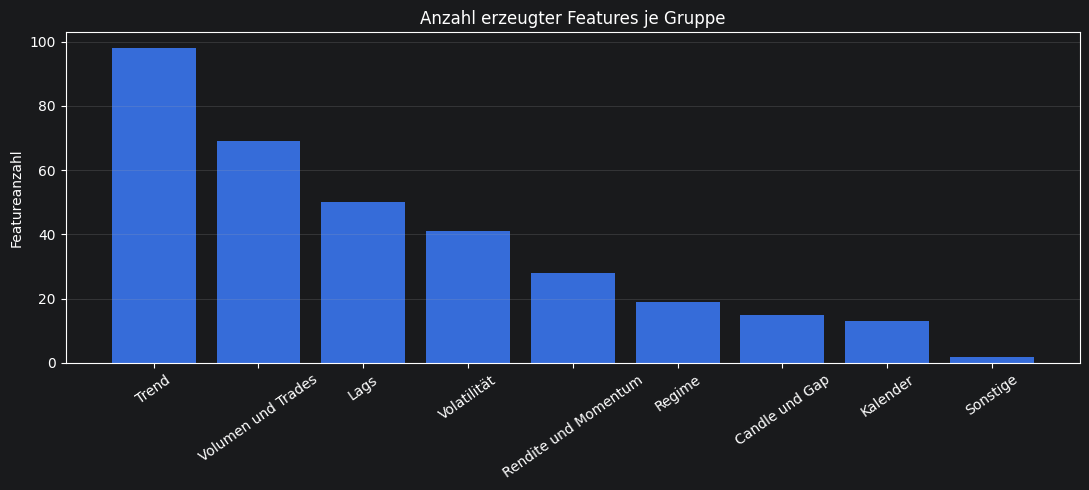

In [7]:
def feature_group(column: str) -> str:
    if column.startswith("lag_"):
        return "Lags"

    if column.startswith("calendar_"):
        return "Kalender"

    if column.startswith(
        ("regime_", "drawdown_")
    ):
        return "Regime"

    if column.startswith(
        (
            "volatility_",
            "atr_",
            "parkinson_",
            "garman_klass_",
            "true_range_",
            "return_squared_",
            "return_absolute_",
        )
    ):
        return "Volatilität"

    if column.startswith(
        (
            "volume_",
            "quote_volume_",
            "trade_count_",
            "taker_",
            "average_volume_",
            "average_quote_",
            "trades_range_",
        )
    ):
        return "Volumen und Trades"

    if column.startswith(
        (
            "sma_",
            "ema_",
            "close_to_",
            "rolling_",
            "rsi_",
            "roc_",
            "bollinger_",
            "macd_",
            "adx_",
            "plus_di_",
            "minus_di_",
            "directional_",
        )
    ):
        return "Trend"

    if column.startswith(
        (
            "candle_",
            "upper_wick_",
            "lower_wick_",
            "close_location",
            "body_to_",
            "is_",
            "open_gap_",
            "gap_",
        )
    ):
        return "Candle und Gap"

    if column.startswith(
        ("return_", "momentum_")
    ):
        return "Rendite und Momentum"

    return "Sonstige"


feature_catalog = pd.DataFrame(
    {
        "feature": feature_columns,
        "group": [
            feature_group(column)
            for column in feature_columns
        ],
        "dtype": [
            str(feature_df[column].dtype)
            for column in feature_columns
        ],
        "missing": [
            int(feature_df[column].isna().sum())
            for column in feature_columns
        ],
        "unique": [
            int(
                feature_df[column].nunique(
                    dropna=True
                )
            )
            for column in feature_columns
        ],
    }
).sort_values(
    ["group", "feature"]
).reset_index(drop=True)

group_counts = (
    feature_catalog
    .groupby("group", observed=True)
    .size()
    .rename("feature_count")
    .sort_values(ascending=False)
    .reset_index()
)

display(group_counts)
display(feature_catalog.head(40))

figure, axis = plt.subplots(figsize=(11, 5))
axis.bar(
    group_counts["group"],
    group_counts["feature_count"],
)
axis.set_title(
    "Anzahl erzeugter Features je Gruppe"
)
axis.set_ylabel("Featureanzahl")
axis.tick_params(axis="x", rotation=35)
axis.grid(True, axis="y", alpha=0.25)
figure.tight_layout()
display(figure)
plt.close(figure)

## 8. Warm-up-Phase

Rolling Windows, Volatility-of-Volatility und Lag-Features
benötigen historische Beobachtungen. Nur die führende
Warm-up-Phase darf entfernt werden.

,Demozeilen,Konfigurierter Lookback,Erste vollständige Position,Warm-up-Zeilen,NaN nach Warm-up
0,1184,672,383,672,0


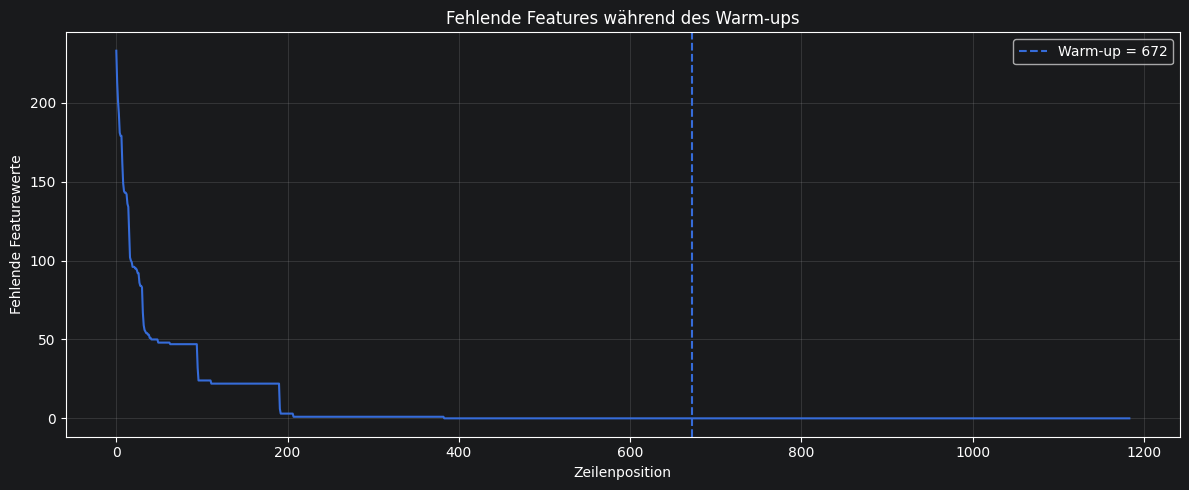

In [8]:
demo_size = min(
    len(raw_df),
    maximum_history + DEMO_EXTRA_ROWS,
)
demo_raw = raw_df.head(demo_size).copy()

demo_full = build_feature_frame(
    demo_raw,
    SETTINGS,
    drop_warmup=False,
)

demo_feature_columns = list(
    demo_full.attrs["feature_columns"]
)
warmup_rows = int(
    demo_full.attrs["warmup_rows"]
)
missing_per_row = (
    demo_full[demo_feature_columns]
    .isna()
    .sum(axis=1)
)

warmup_summary = pd.DataFrame(
    [
        {
            "Demozeilen": len(demo_full),
            "Konfigurierter Lookback": (
                demo_full.attrs[
                    "configured_maximum_history_candles"
                ]
            ),
            "Erste vollständige Position": (
                demo_full.attrs[
                    "first_complete_feature_position"
                ]
            ),
            "Warm-up-Zeilen": warmup_rows,
            "NaN nach Warm-up": int(
                demo_full
                .iloc[warmup_rows:][
                    demo_feature_columns
                ]
                .isna()
                .sum()
                .sum()
            ),
        }
    ]
)
display(warmup_summary)

figure, axis = plt.subplots(figsize=(12, 5))
axis.plot(
    np.arange(len(missing_per_row)),
    missing_per_row,
)
axis.axvline(
    warmup_rows,
    linestyle="--",
    label=f"Warm-up = {warmup_rows}",
)
axis.set_title(
    "Fehlende Features während des Warm-ups"
)
axis.set_xlabel("Zeilenposition")
axis.set_ylabel("Fehlende Featurewerte")
axis.grid(True, alpha=0.25)
axis.legend()
figure.tight_layout()
display(figure)
plt.close(figure)

## 9. Leakage- und Determinismusprüfung

Beim Präfixinvarianztest werden zukünftige Kerzen stark
verändert. Bereits berechnete frühere Features dürfen sich
dadurch nicht verändern.

In [9]:
if RUN_LEAKAGE_TESTS:
    prefix_check = validate_prefix_invariance(
        raw_df,
        SETTINGS,
    )
    determinism_check = validate_determinism(
        raw_df,
        SETTINGS,
    )
else:
    prefix_check = {
        "passed": False,
        "skipped": True,
    }
    determinism_check = {
        "passed": False,
        "skipped": True,
    }

checks = pd.DataFrame(
    [
        {
            "check": "prefix_invariance",
            **prefix_check,
        },
        {
            "check": "determinism",
            **determinism_check,
        },
    ]
)
display(checks)

if RUN_LEAKAGE_TESTS:
    assert prefix_check["passed"]
    assert determinism_check["passed"]

,check,passed,skipped,prefix_rows,extended_rows,comparison_rows,feature_count,future_rows_perturbed,sample_rows,fingerprint
0,prefix_invariance,True,False,"1,024.000000","1,152.000000",352.000000,335.000000,128.000000,NaN,NaN
1,determinism,True,NaN,NaN,NaN,NaN,NaN,NaN,"1,024.000000",2c3916494de38d7e19eaf134865a7b0bef22aca5c6553d...


## 10. Trendindikatoren

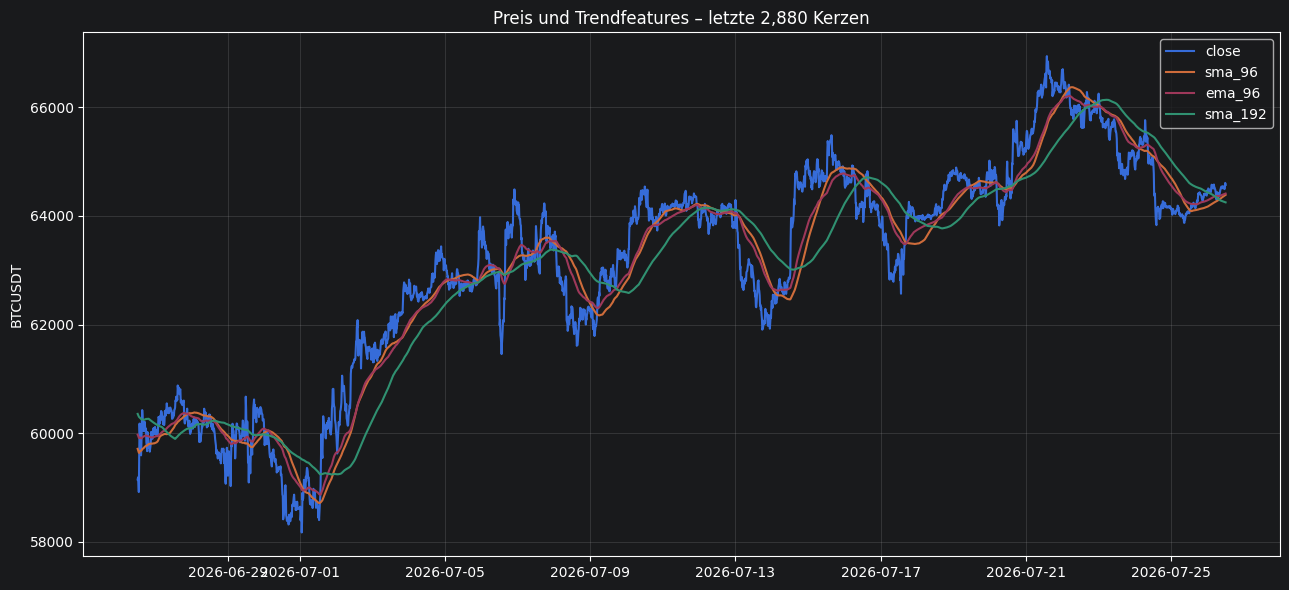

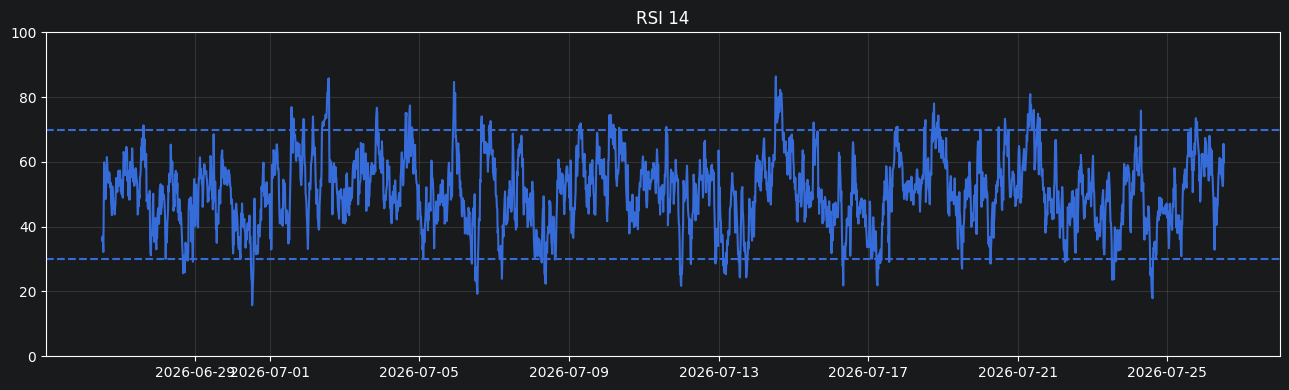

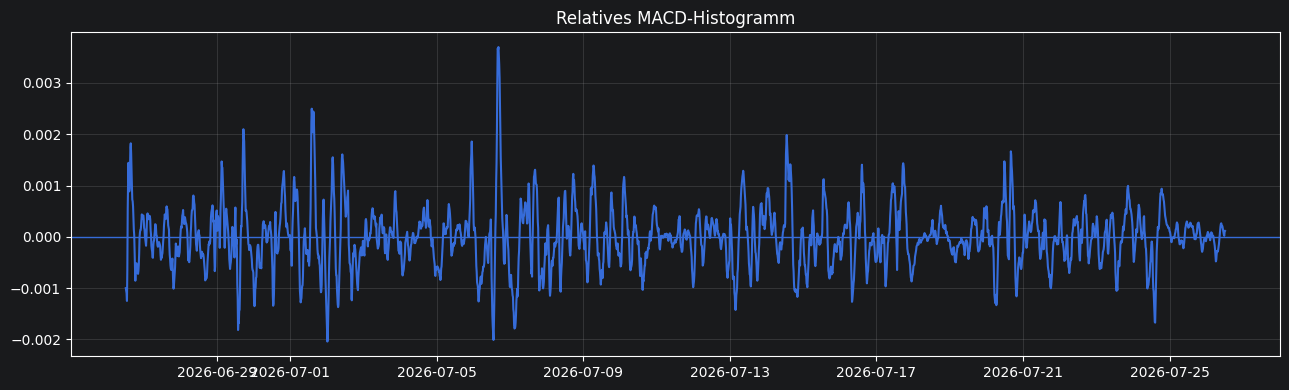

In [10]:
recent = feature_df.tail(
    RECENT_CANDLES
).copy()
recent_time = pd.to_datetime(
    recent["open_time"],
    utc=True,
)

trend_columns = [
    column
    for column in (
        "close",
        "sma_96",
        "ema_96",
        "sma_192",
    )
    if column in recent.columns
]

figure, axis = plt.subplots(figsize=(13, 6))
for column in trend_columns:
    axis.plot(
        recent_time,
        recent[column],
        label=column,
    )

axis.set_title(
    f"Preis und Trendfeatures – "
    f"letzte {len(recent):,} Kerzen"
)
axis.set_ylabel("BTCUSDT")
axis.grid(True, alpha=0.25)
axis.legend()
figure.tight_layout()
display(figure)
plt.close(figure)

if "rsi_14" in recent.columns:
    figure, axis = plt.subplots(
        figsize=(13, 4)
    )
    axis.plot(
        recent_time,
        recent["rsi_14"],
    )
    axis.axhline(70, linestyle="--")
    axis.axhline(30, linestyle="--")
    axis.set_title("RSI 14")
    axis.set_ylim(0, 100)
    axis.grid(True, alpha=0.25)
    figure.tight_layout()
    display(figure)
    plt.close(figure)

if "macd_histogram_relative" in recent.columns:
    figure, axis = plt.subplots(
        figsize=(13, 4)
    )
    axis.plot(
        recent_time,
        recent[
            "macd_histogram_relative"
        ],
    )
    axis.axhline(0, linewidth=1)
    axis.set_title(
        "Relatives MACD-Histogramm"
    )
    axis.grid(True, alpha=0.25)
    figure.tight_layout()
    display(figure)
    plt.close(figure)

## 11. Renditen und Volatilität

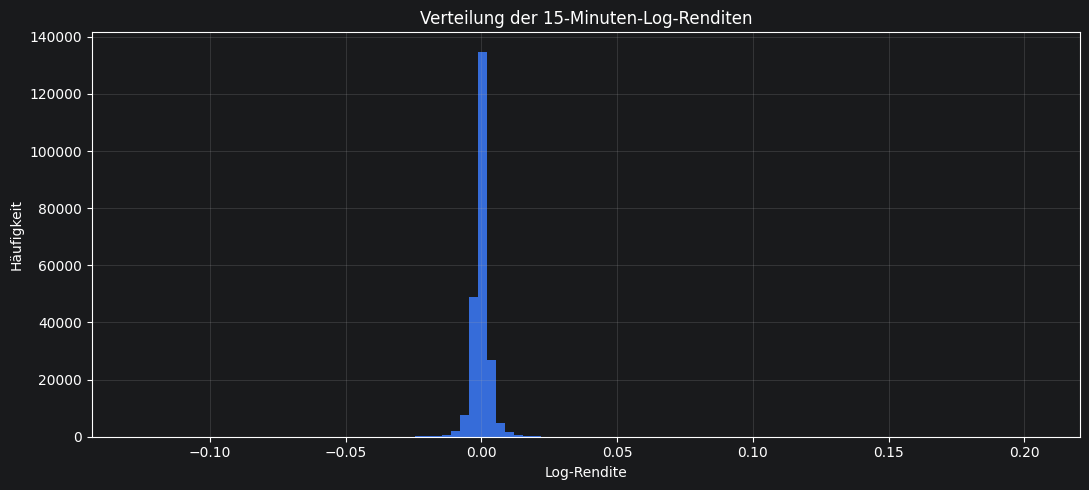

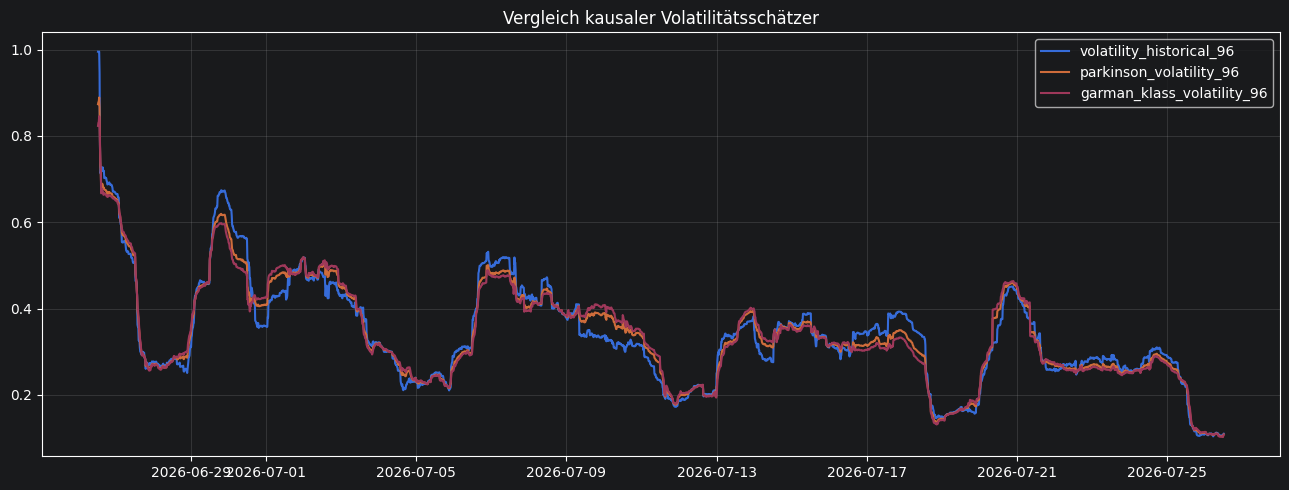

,count,mean,std,min,1%,5%,50%,95%,99%,max
volatility_historical_96,"229,434.000000",0.528264,0.350571,0.052308,0.121080,0.184513,0.454901,1.116808,1.763365,7.174288
parkinson_volatility_96,"229,434.000000",0.550130,0.363123,0.037841,0.123525,0.191832,0.474865,1.139772,1.897343,6.878457
garman_klass_volatility_96,"229,434.000000",0.557370,0.369648,0.029685,0.121917,0.193142,0.479591,1.156377,1.941005,6.768500


In [11]:
if "return_log_1" in feature_df.columns:
    figure, axis = plt.subplots(
        figsize=(11, 5)
    )
    axis.hist(
        feature_df[
            "return_log_1"
        ].dropna(),
        bins=100,
    )
    axis.set_title(
        "Verteilung der "
        "15-Minuten-Log-Renditen"
    )
    axis.set_xlabel("Log-Rendite")
    axis.set_ylabel("Häufigkeit")
    axis.grid(True, alpha=0.25)
    figure.tight_layout()
    display(figure)
    plt.close(figure)

volatility_columns = [
    column
    for column in (
        "volatility_historical_96",
        "parkinson_volatility_96",
        "garman_klass_volatility_96",
    )
    if column in recent.columns
]

if volatility_columns:
    figure, axis = plt.subplots(
        figsize=(13, 5)
    )

    for column in volatility_columns:
        axis.plot(
            recent_time,
            recent[column],
            label=column,
        )

    axis.set_title(
        "Vergleich kausaler "
        "Volatilitätsschätzer"
    )
    axis.grid(True, alpha=0.25)
    axis.legend()
    figure.tight_layout()
    display(figure)
    plt.close(figure)

    display(
        feature_df[
            volatility_columns
        ].describe(
            percentiles=[
                0.01,
                0.05,
                0.50,
                0.95,
                0.99,
            ]
        ).T
    )

## 12. Volumen, Trades und Taker-Imbalance

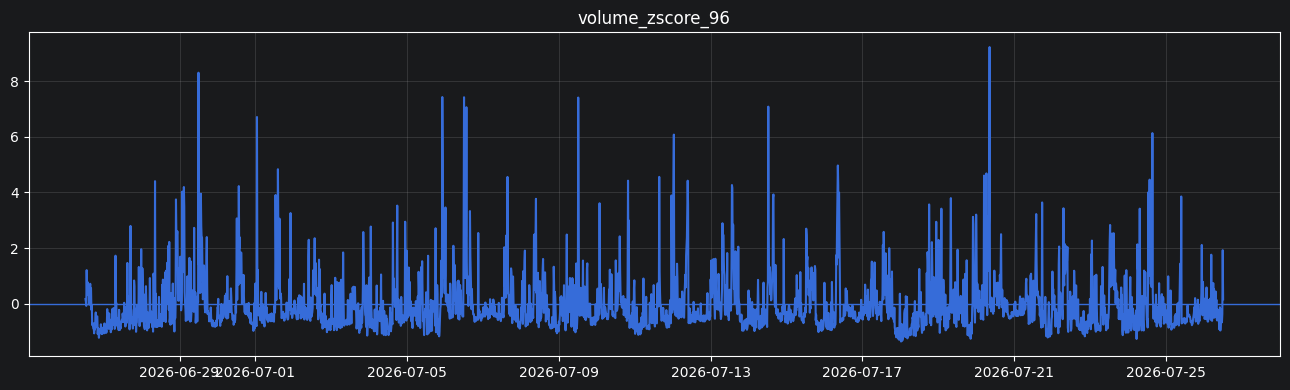

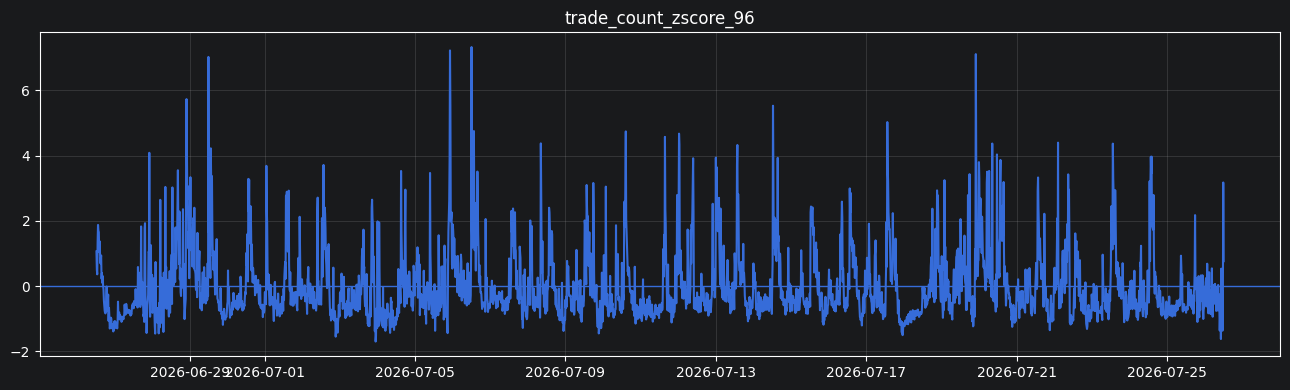

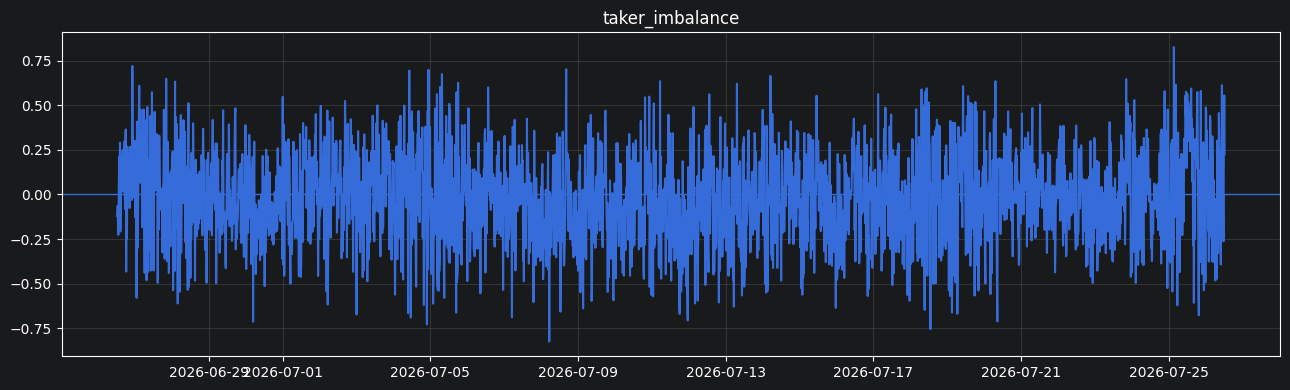

,zero_volume_indicator,zero_trade_indicator
0,13,13


In [12]:
diagnostic_columns = [
    column
    for column in (
        "volume_zscore_96",
        "trade_count_zscore_96",
        "taker_imbalance",
    )
    if column in recent.columns
]

for column in diagnostic_columns:
    figure, axis = plt.subplots(
        figsize=(13, 4)
    )
    axis.plot(
        recent_time,
        recent[column],
    )
    axis.axhline(0, linewidth=1)
    axis.set_title(column)
    axis.grid(True, alpha=0.25)
    figure.tight_layout()
    display(figure)
    plt.close(figure)

zero_summary = {
    column: int(feature_df[column].sum())
    for column in (
        "zero_volume_indicator",
        "zero_trade_indicator",
    )
    if column in feature_df.columns
}
display(pd.DataFrame([zero_summary]))

## 13. Kalendermerkmale und zyklische Kodierung

,encoding,mean_radius_squared,maximum_deviation
0,hour,1.000000,0.000000
1,weekday,1.000000,0.000000
2,month,1.000000,0.000000


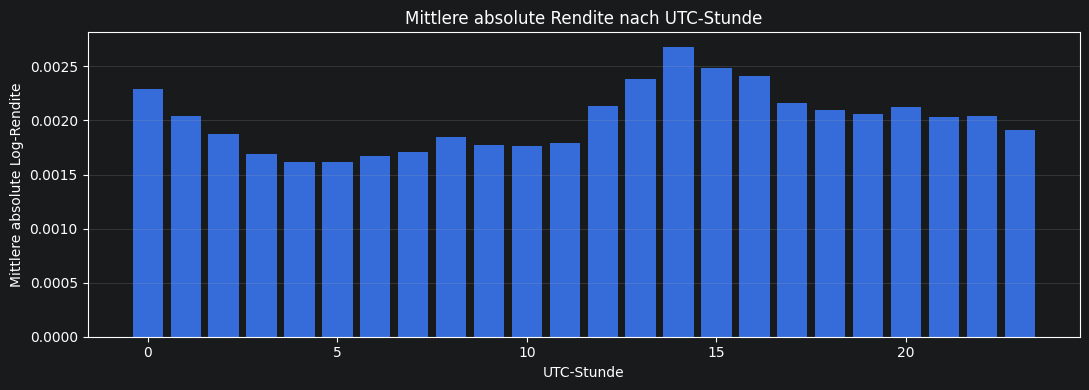

In [13]:
cyclic_checks = []

for name in ("hour", "weekday", "month"):
    sin_column = f"calendar_{name}_sin"
    cos_column = f"calendar_{name}_cos"

    if (
        sin_column in feature_df.columns
        and cos_column in feature_df.columns
    ):
        radius_squared = (
            feature_df[sin_column].pow(2)
            + feature_df[cos_column].pow(2)
        )

        cyclic_checks.append(
            {
                "encoding": name,
                "mean_radius_squared": float(
                    radius_squared.mean()
                ),
                "maximum_deviation": float(
                    (
                        radius_squared - 1
                    ).abs().max()
                ),
            }
        )

display(pd.DataFrame(cyclic_checks))

required_hourly = {
    "calendar_hour_utc",
    "return_absolute_1",
}

if required_hourly.issubset(
    feature_df.columns
):
    hourly = (
        feature_df
        .groupby(
            "calendar_hour_utc",
            observed=True,
        )["return_absolute_1"]
        .mean()
        .reset_index()
    )

    figure, axis = plt.subplots(
        figsize=(11, 4)
    )
    axis.bar(
        hourly["calendar_hour_utc"],
        hourly["return_absolute_1"],
    )
    axis.set_title(
        "Mittlere absolute Rendite "
        "nach UTC-Stunde"
    )
    axis.set_xlabel("UTC-Stunde")
    axis.set_ylabel(
        "Mittlere absolute Log-Rendite"
    )
    axis.grid(
        True,
        axis="y",
        alpha=0.25,
    )
    figure.tight_layout()
    display(figure)
    plt.close(figure)

## 14. Marktregime

,regime,code,ratio
0,regime_trend_code,-1,0.293827
1,regime_trend_code,0,0.364022
2,regime_trend_code,1,0.342151
3,regime_volatility_code,-1,0.525698
4,regime_volatility_code,0,0.294525
5,regime_volatility_code,1,0.179777
6,regime_drawdown_code,0,0.126660
7,regime_drawdown_code,1,0.242466
8,regime_drawdown_code,2,0.630874
9,regime_volume_code,-1,0.020825


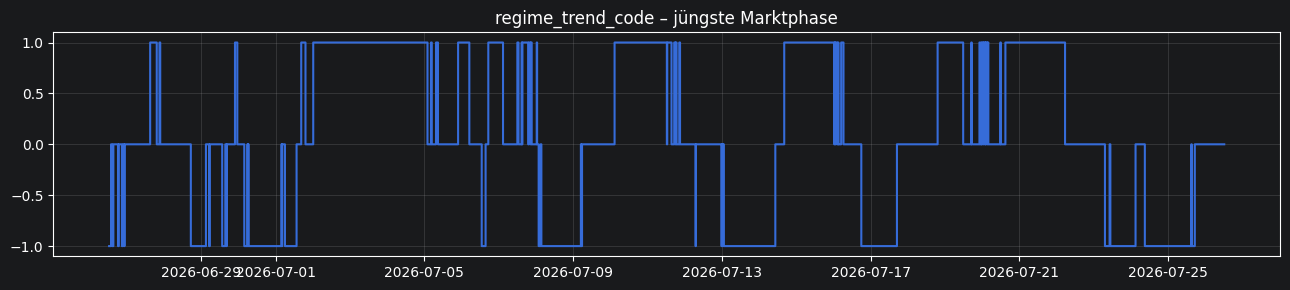

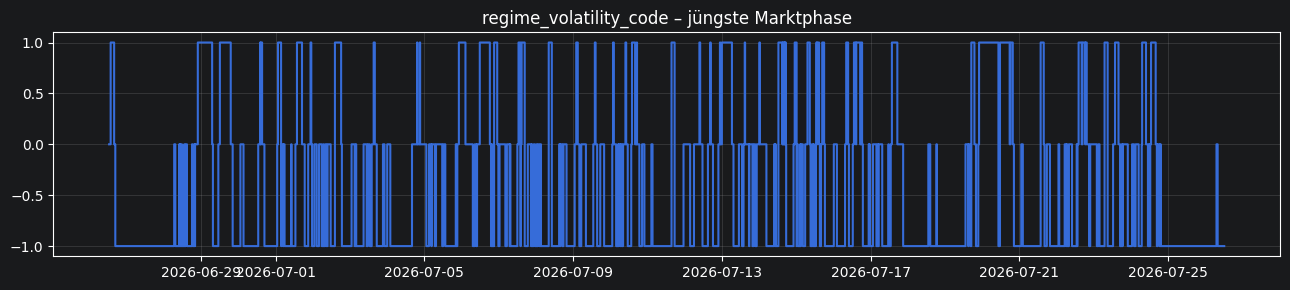

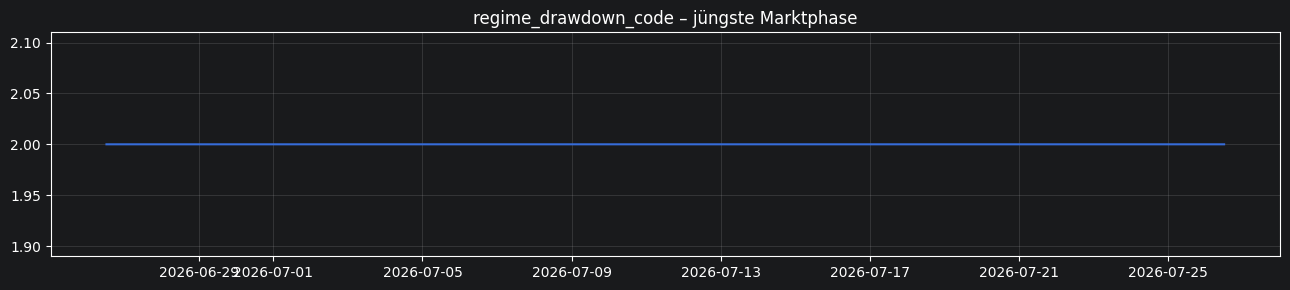

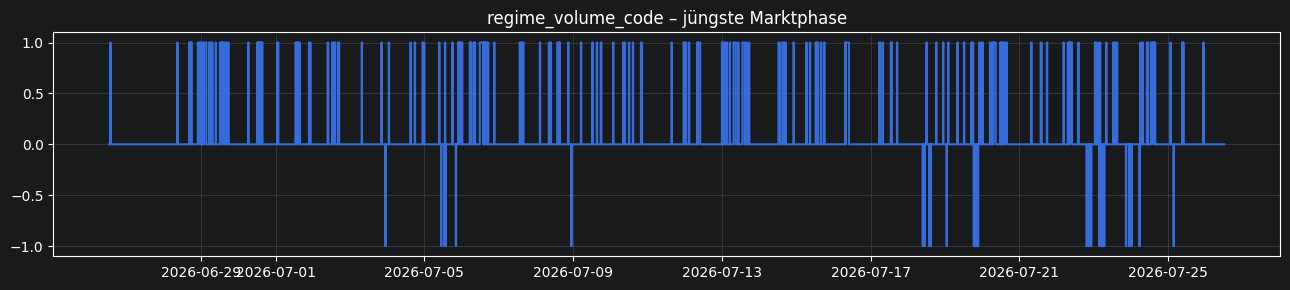

In [14]:
regime_columns = [
    column
    for column in (
        "regime_trend_code",
        "regime_volatility_code",
        "regime_drawdown_code",
        "regime_volume_code",
    )
    if column in feature_df.columns
]

regime_rows = []

for column in regime_columns:
    ratios = (
        feature_df[column]
        .value_counts(normalize=True)
        .sort_index()
    )

    for value, ratio in ratios.items():
        regime_rows.append(
            {
                "regime": column,
                "code": int(value),
                "ratio": float(ratio),
            }
        )

display(pd.DataFrame(regime_rows))

for column in regime_columns:
    figure, axis = plt.subplots(
        figsize=(13, 3)
    )
    axis.step(
        recent_time,
        recent[column],
        where="post",
    )
    axis.set_title(
        f"{column} – jüngste Marktphase"
    )
    axis.grid(True, alpha=0.25)
    figure.tight_layout()
    display(figure)
    plt.close(figure)

## 15. Lag-Konsistenz

In [15]:
lag_examples = [
    column
    for column in (
        "lag_return_log_1_1",
        "lag_return_log_1_4",
        "lag_rsi_14_8",
        "lag_taker_imbalance_16",
    )
    if column in feature_df.columns
]

lag_checks = []

for lag_column in lag_examples:
    remainder = lag_column.removeprefix(
        "lag_"
    )
    base_column, lag_text = (
        remainder.rsplit("_", 1)
    )
    lag = int(lag_text)

    expected = feature_df[
        base_column
    ].shift(lag)

    comparable = (
        feature_df[lag_column].notna()
        & expected.notna()
    )

    maximum_error = float(
        (
            feature_df.loc[
                comparable,
                lag_column,
            ]
            - expected.loc[comparable]
        )
        .abs()
        .max()
    )

    lag_checks.append(
        {
            "lag_feature": lag_column,
            "base_feature": base_column,
            "lag": lag,
            "maximum_absolute_error": (
                maximum_error
            ),
            "passed": (
                maximum_error <= 1e-12
            ),
        }
    )

lag_check_frame = pd.DataFrame(
    lag_checks
)
display(lag_check_frame)

assert lag_check_frame["passed"].all()

,lag_feature,base_feature,lag,maximum_absolute_error,passed
0,lag_return_log_1_1,return_log_1,1,0.000000,True
1,lag_return_log_1_4,return_log_1,4,0.000000,True
2,lag_rsi_14_8,rsi_14,8,0.000000,True
3,lag_taker_imbalance_16,taker_imbalance,16,0.000000,True


## 16. Korrelationsdiagnostik

Die vollständige Matrix mit mehreren hundert Features wäre
unübersichtlich. Daher wird eine fachlich interpretierbare
Auswahl dargestellt.

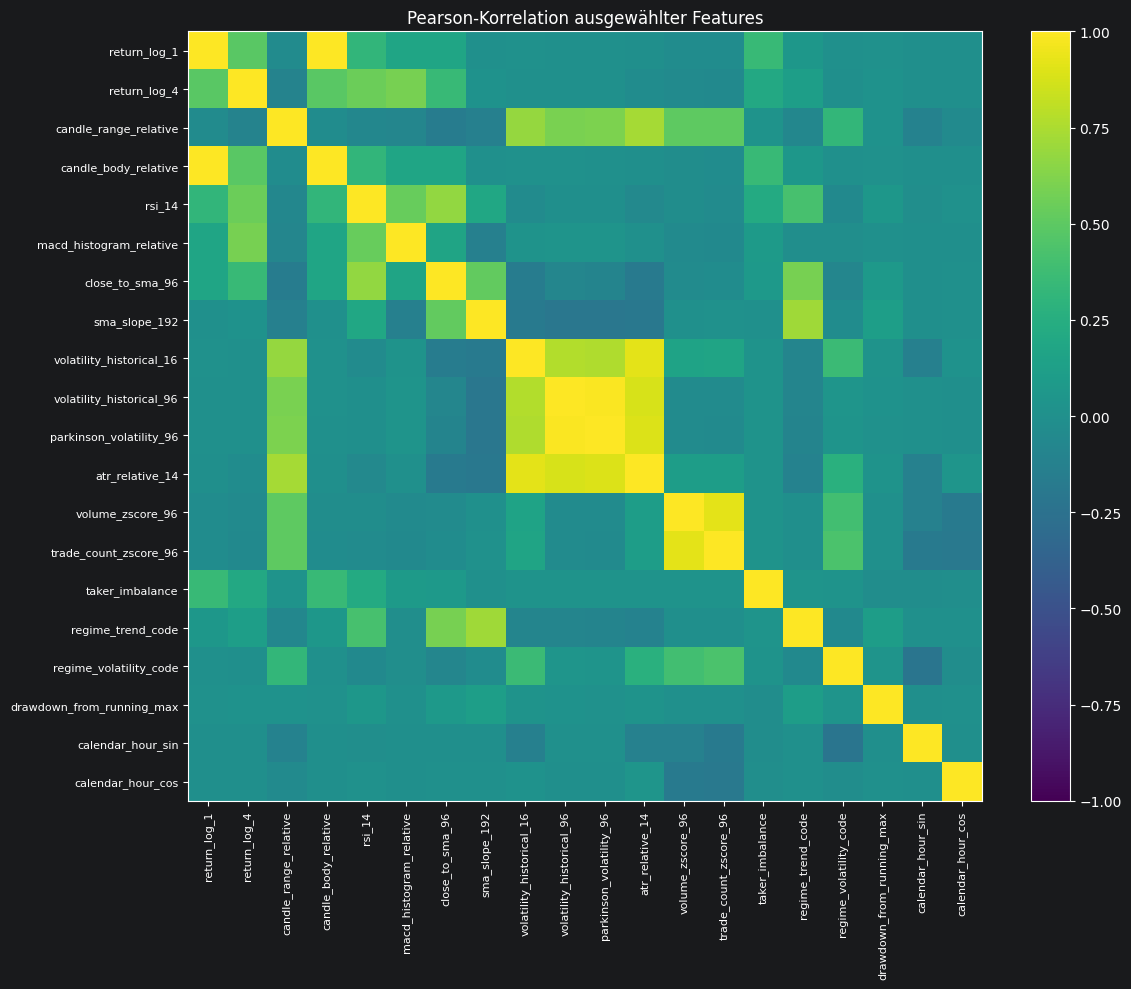

,feature_a,feature_b,correlation,absolute_correlation
0,return_log_1,candle_body_relative,0.999754,0.999754
1,volatility_historical_96,parkinson_volatility_96,0.986161,0.986161
2,volatility_historical_16,atr_relative_14,0.915806,0.915806
3,volume_zscore_96,trade_count_zscore_96,0.915476,0.915476
4,parkinson_volatility_96,atr_relative_14,0.896156,0.896156
5,volatility_historical_96,atr_relative_14,0.882178,0.882178
6,volatility_historical_16,volatility_historical_96,0.769009,0.769009
7,volatility_historical_16,parkinson_volatility_96,0.761745,0.761745
8,candle_range_relative,atr_relative_14,0.726685,0.726685
9,sma_slope_192,regime_trend_code,0.717772,0.717772


In [16]:
preferred_features = [
    "return_log_1",
    "return_log_4",
    "candle_range_relative",
    "candle_body_relative",
    "rsi_14",
    "macd_histogram_relative",
    "close_to_sma_96",
    "sma_slope_192",
    "volatility_historical_16",
    "volatility_historical_96",
    "parkinson_volatility_96",
    "atr_relative_14",
    "volume_zscore_96",
    "trade_count_zscore_96",
    "taker_imbalance",
    "regime_trend_code",
    "regime_volatility_code",
    "drawdown_from_running_max",
    "calendar_hour_sin",
    "calendar_hour_cos",
]

selected_features = [
    column
    for column in preferred_features
    if column in feature_df.columns
][:MAXIMUM_CORRELATION_FEATURES]

correlation = feature_df[
    selected_features
].corr()

figure, axis = plt.subplots(
    figsize=(12, 10)
)
image = axis.imshow(
    correlation.to_numpy(),
    aspect="auto",
    vmin=-1,
    vmax=1,
)

axis.set_xticks(
    range(len(selected_features))
)
axis.set_xticklabels(
    selected_features,
    rotation=90,
    fontsize=8,
)
axis.set_yticks(
    range(len(selected_features))
)
axis.set_yticklabels(
    selected_features,
    fontsize=8,
)
axis.set_title(
    "Pearson-Korrelation "
    "ausgewählter Features"
)
figure.colorbar(image, ax=axis)
figure.tight_layout()
display(figure)
plt.close(figure)

pairs = []

for left_index, left in enumerate(
    selected_features
):
    for right in selected_features[
        left_index + 1:
    ]:
        value = correlation.loc[
            left,
            right,
        ]

        if pd.notna(value):
            pairs.append(
                {
                    "feature_a": left,
                    "feature_b": right,
                    "correlation": float(value),
                    "absolute_correlation": abs(
                        float(value)
                    ),
                }
            )

display(
    pd.DataFrame(pairs)
    .sort_values(
        "absolute_correlation",
        ascending=False,
    )
    .head(25)
    .reset_index(drop=True)
)

## 17. Stabilität zentraler Features nach Jahr

In [17]:
stability_features = [
    column
    for column in (
        "return_log_1",
        "volatility_historical_96",
        "volume_zscore_96",
        "taker_imbalance",
        "rsi_14",
    )
    if column in feature_df.columns
]

stability_frame = feature_df[
    ["open_time", *stability_features]
].copy()

stability_frame["year"] = (
    pd.to_datetime(
        stability_frame["open_time"],
        utc=True,
    ).dt.year
)

yearly_stability = (
    stability_frame
    .groupby(
        "year",
        observed=True,
    )[stability_features]
    .agg(["mean", "std", "median"])
)

display(yearly_stability)

return_log_1                    volatility_historical_96                   volume_zscore_96                    taker_imbalance                       rsi_14                    
             mean      std    median                     mean      std   median             mean      std    median            mean      std    median      mean       std    median
year                                                                                                                                                                                
2020     0.000037 0.004096  0.000051                 0.587060 0.493855 0.484723        -0.003030 1.073560 -0.298731       -0.028679 0.146374 -0.032466 51.332430 10.834036 51.390946
2021     0.000013 0.004928 -0.000013                 0.816544 0.431327 0.703100         0.005275 1.073722 -0.302404       -0.015663 0.115193 -0.017565 50.578835 11.426716 50.681944
2022    -0.000029 0.003420  0.000007                 0.564582 0.302982 0.511406         0.003984 1.080150 -0.308169       -0.008476 0.102742 -0.005817 49.635835 11.472019 49.747423
2023     0.000027 0.002310  0.000011                 0.376585 0.212131 0.344262         0.005512 1.085698 -0.310758       -0.031719 0.161616 -0.020258 50.550494 10.879026 50.308028
2024     0.000023 0.002831  0.000017                 0.483159 0.217618 0.446217         0.015441 1.104671 -0.319626       -0.019376 0.188984 -0.018875 50.864817 10.992161 50.924308
2025    -0.000002 0.002384 -0.000000                 0.401337 0.196366 0.363945         0.021210 1.113058 -0.320492       -0.041348 0.241302 -0.043655 50.249354 11.300353 50.441023
2026    -0.000015 0.002506 -0.000013                 0.425862 0.197802 0.395994         0.011486 1.076667 -0.313868       -0.010992 0.254394 -0.010792 49.774408 11.230510 49.832035

## 18. Abschließendes Freigabegate

In [18]:
feature_values = feature_df[
    feature_columns
]
numeric_values = (
    feature_values
    .to_numpy(
        dtype="float64",
        copy=True,
    )
)

forbidden_columns = [
    column
    for column in feature_df.columns
    if any(
        fragment in column.lower()
        for fragment in (
            "target",
            "future",
            "label",
            "prediction",
            "y_true",
        )
    )
]

release_checks = pd.DataFrame(
    [
        {
            "check": "Candle-Qualitätsgate",
            "passed": quality_report.is_valid,
        },
        {
            "check": "Feature-Validierung",
            "passed": feature_report.is_valid,
        },
        {
            "check": (
                "Keine fehlenden Featurewerte"
            ),
            "passed": (
                int(
                    feature_values
                    .isna()
                    .sum()
                    .sum()
                )
                == 0
            ),
        },
        {
            "check": (
                "Keine unendlichen Featurewerte"
            ),
            "passed": (
                int(
                    np.isinf(
                        numeric_values
                    ).sum()
                )
                == 0
            ),
        },
        {
            "check": (
                "Keine Target-/Zukunftsspalten"
            ),
            "passed": not forbidden_columns,
        },
        {
            "check": (
                "Chronologisch sortiert"
            ),
            "passed": (
                pd.to_datetime(
                    feature_df["open_time"],
                    utc=True,
                )
                .is_monotonic_increasing
            ),
        },
        {
            "check": (
                "Keine doppelten Schlüssel"
            ),
            "passed": not feature_df.duplicated(
                [
                    "symbol",
                    "interval",
                    "open_time",
                ]
            ).any(),
        },
        {
            "check": "Präfixinvarianz",
            "passed": bool(
                prefix_check.get("passed")
            ),
        },
        {
            "check": "Determinismus",
            "passed": bool(
                determinism_check.get(
                    "passed"
                )
            ),
        },
    ]
)

display(release_checks)

assert release_checks["passed"].all(), (
    "Feature-Freigabegate fehlgeschlagen."
)

display(
    Markdown(
        f"""
### Ergebnis

Der Feature-Datensatz ist für die nächste Pipeline-Stufe
freigegeben.

- **Zeilen:** {len(feature_df):,}
- **Features:** {len(feature_columns):,}
- **Warm-up:** {maximum_history:,} Kerzen
- **Beginn:** {
    pd.to_datetime(
        feature_df["open_time"],
        utc=True,
    ).min()
}
- **Ende:** {
    pd.to_datetime(
        feature_df["open_time"],
        utc=True,
    ).max()
}

"""
    )
)

,check,passed
0,Candle-Qualitätsgate,True
1,Feature-Validierung,True
2,Keine fehlenden Featurewerte,True
3,Keine unendlichen Featurewerte,True
4,Keine Target-/Zukunftsspalten,True
5,Chronologisch sortiert,True
6,Keine doppelten Schlüssel,True
7,Präfixinvarianz,True
8,Determinismus,True



### Ergebnis

Der Feature-Datensatz ist für die nächste Pipeline-Stufe
freigegeben.

- **Zeilen:** 229,434
- **Features:** 335
- **Warm-up:** 672 Kerzen
- **Beginn:** 2020-01-08 00:00:00+00:00
- **Ende:** 2026-07-26 12:15:00+00:00

Der nächste Schritt ist `04_target_engineering.ipynb`.
